## Processing PRISMA Hyperspectral Imagery using Python ##
---

This notebook introduces the geometric and radiometric correction of hyperspectral images acquired by the PRISMA satellite. The workflow demonstrates how to improve spatial shifts and spectral quality of PRISMA images for subsequent remote sensing analyses.

The workflow incorporates two main preprocessing steps:

**1. Geometric Correction**  
Correcting spatial misalignment between PRISMA images and a reference satellite image (Landsat 30 m resolution) using the AROSICS co-registration algorithm.

**2. Radiometric Correction**  
Removing spectral bands affected by atmospheric water absorption and noisy bands identified through comparison with field-measured spectra of grass using an ASD FieldSpec spectroradiometer.

This preprocessing ensures that the hyperspectral data are accurately aligned and spectrally clean for further analysis.


## Input data ##
---

- PRISMA hyperspectral image (target)
- Landsat band 5 (NIR) with 30 m spatial resolution (reference for geometric correction)

## General structure of notebook ##
---

**1. Geometric correction**  
1.1. Import required libraries and define paths  
1.2. Define parameters for correction  
1.3. Visualize tie point grid with INITIAL shifts   
1.4. Visualize tie point grid AFTER shift correction  

**2. Radiometric correction**  
2.1. Import required libraries and define paths  
2.2. Convert .bsq to .GEotiff format  
2.3. Define bands to remove  
2.4. Remove bands  
2.5. Save the corrected image

## Acknowledgements ##
---

This work is supported by the [EO Africa R&D Facility](https://www.eoafrica-rd.org/), a joint initiative of ESA and the African Union Commission, in the context of the bilateral research project 02_SEMHY-ARID_ET_ES_EOAC3 between Wollo University (Ethiopia) and Spanish National Research Council  (Spain) (ESA Contract No. 4000133905/21/I-EF).

<div style="display:flex; gap:20px; align-items:center;">
    <img src="images/EOAFRICA-logo.png" width="130">
    <img src="images/SEMHy-ARID_logo.png" width="180">
</div>

## 0. Download sample dataset ##
In order to run with the sample dataset, download from [here](https://saco.csic.es/s/43Doj2XAWztLRt2)

Copy the image data from above link to your local folder in the *images* folder **(/images)**. 

The output is also provided in the above link for reference.

## 1. Geometric correction ##

**1.1. Import required libraries and define paths** 

In [1]:
from arosics import COREG_LOCAL
from pathlib import Path

project_dir = Path.cwd()

images_dir = project_dir / "images"
output_dir = project_dir / "output"
if not output_dir.exists():
    output_dir.mkdir()
    
# remember to copy sample dataset to images_dir folder
im_target = images_dir / "Prisma_L2D_STD_20230125.envi"
im_reference = images_dir / "Landsat_reference_B5.tif"
print('Done!')

Done!


**1.2. Define parameters for correction** 

In [2]:
kwargs = {
    'grid_res'     : 30, 
    'window_size'  : (256,256), 
    'path_out'     : 'auto',
    's_b4match' : 51,  ## Change the band it takes from the image we want to correct. By default it takes band 1. PRISMA 51 = 871 nm
    'tieP_filter_level' : 3,
    'projectDir'   : 'output',
    'q'            : False,
    'resamp_alg_deshift' : 'nearest',
    'match_gsd' : 'TRUE', ## Match PRISMA pixel to Landast pixel reference
    'max_shift' : 30, ## Default 5. Modify to higher value, 20, 30, if the offset is high (to find pixels)     
    'min_reliability' : 60, 
}
CRL = COREG_LOCAL(str(im_reference), str(im_target),**kwargs)

CRL.correct_shifts()
print('Done!')

Calculating footprint polygon and actual data corner coordinates for reference image...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for reference image:
	(344085.0, 523635.0, 567105.0, 754425.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(395867.5, 561862.5, 431597.5, 597382.5)
Matching window position (X,Y): 413732.5/579622.5
Initializing tie points grid...


Warping progress     |==================================================| 100.0% Complete  => 0:00:00


Equalizing pixel grids and projections of reference and target image...


...

Calculating tie point grid (1600 points) using 12 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:38


Found 1343 matches.
Performing validity checks...
110 tie points flagged by level 1 filtering (reliability).
14 tie points flagged by level 2 filtering (SSIM).
126 tie points flagged by level 3 filtering (RANSAC)
1106 valid tie points remain after filtering.
Correcting geometric shifts...


Translating progress |==================================================| 100.0% Complete  => 0:00:00
Warping progress     |==================================================| 100.0% Complete  => 0:00:03


Writing GeoArray of size (1183, 1190, 230) to C:\Users\50614603K\Corrección_arosics\PRISMA_preprocessing_codigo_github\prisma-image-preprocessing\output\Prisma_L2D_STD_20230125__shifted_to__Landsat_reference_B5.bsq.
Done!


**1.3. Visualize tie point grid with INITIAL shifts** 

Note: array has been downsampled to 980 x 1000 for faster visualization.


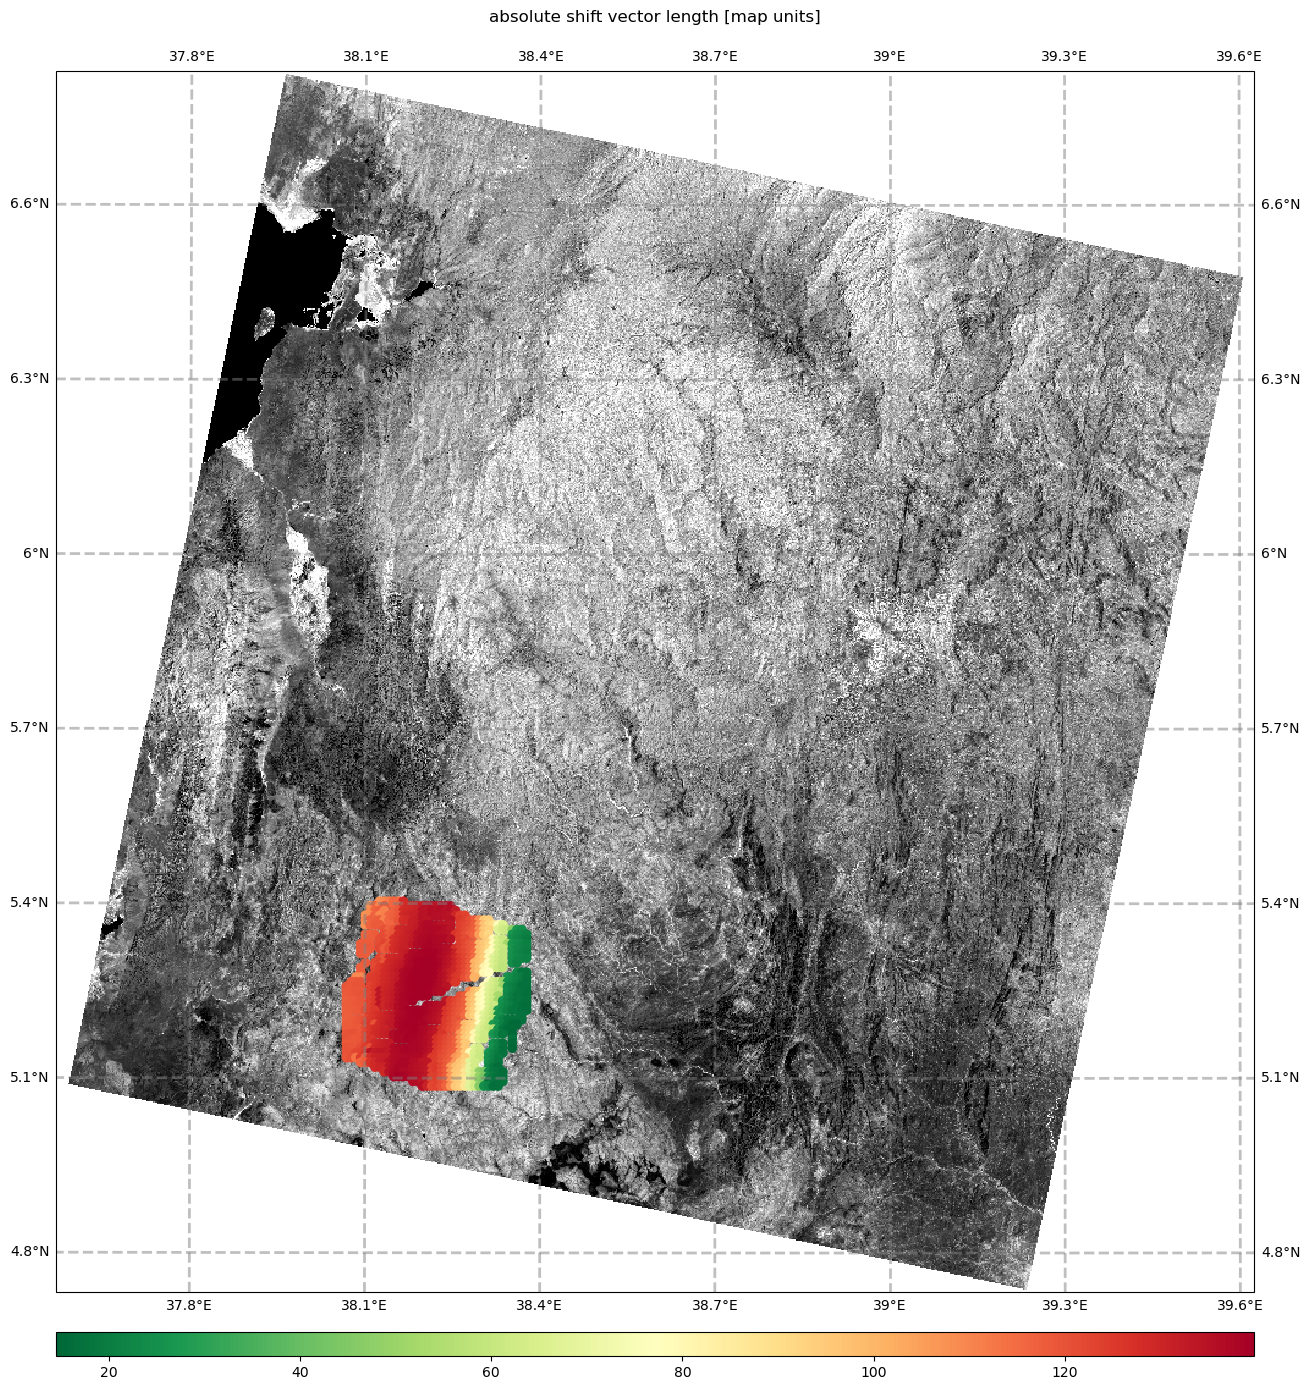

In [3]:
CRL.view_CoRegPoints(figsize=(15,15), backgroundIm='ref')


**1.4. Visualize tie point grid AFTER shift correction** 

Calculating footprint polygon and actual data corner coordinates for reference image...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for reference image:
	(344085.0, 523635.0, 567105.0, 754425.0)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for image to be shifted:
	(395895.0, 561885.0, 431595.0, 597375.0)
Matching window position (X,Y): 413743.006631396/579596.7826840715
Note: array has been downsampled to 980 x 1000 for faster visualization.
Initializing tie points grid...
Calculating tie point grid (1562 points) using 12 CPU cores...


	progress: |==================================================| 100.0% Complete  => 0:00:41


Found 1292 matches.
Performing validity checks...
258 tie points flagged by level 1 filtering (reliability).
225 tie points flagged by level 2 filtering (SSIM).
52 tie points flagged by level 3 filtering (RANSAC)
759 valid tie points remain after filtering.


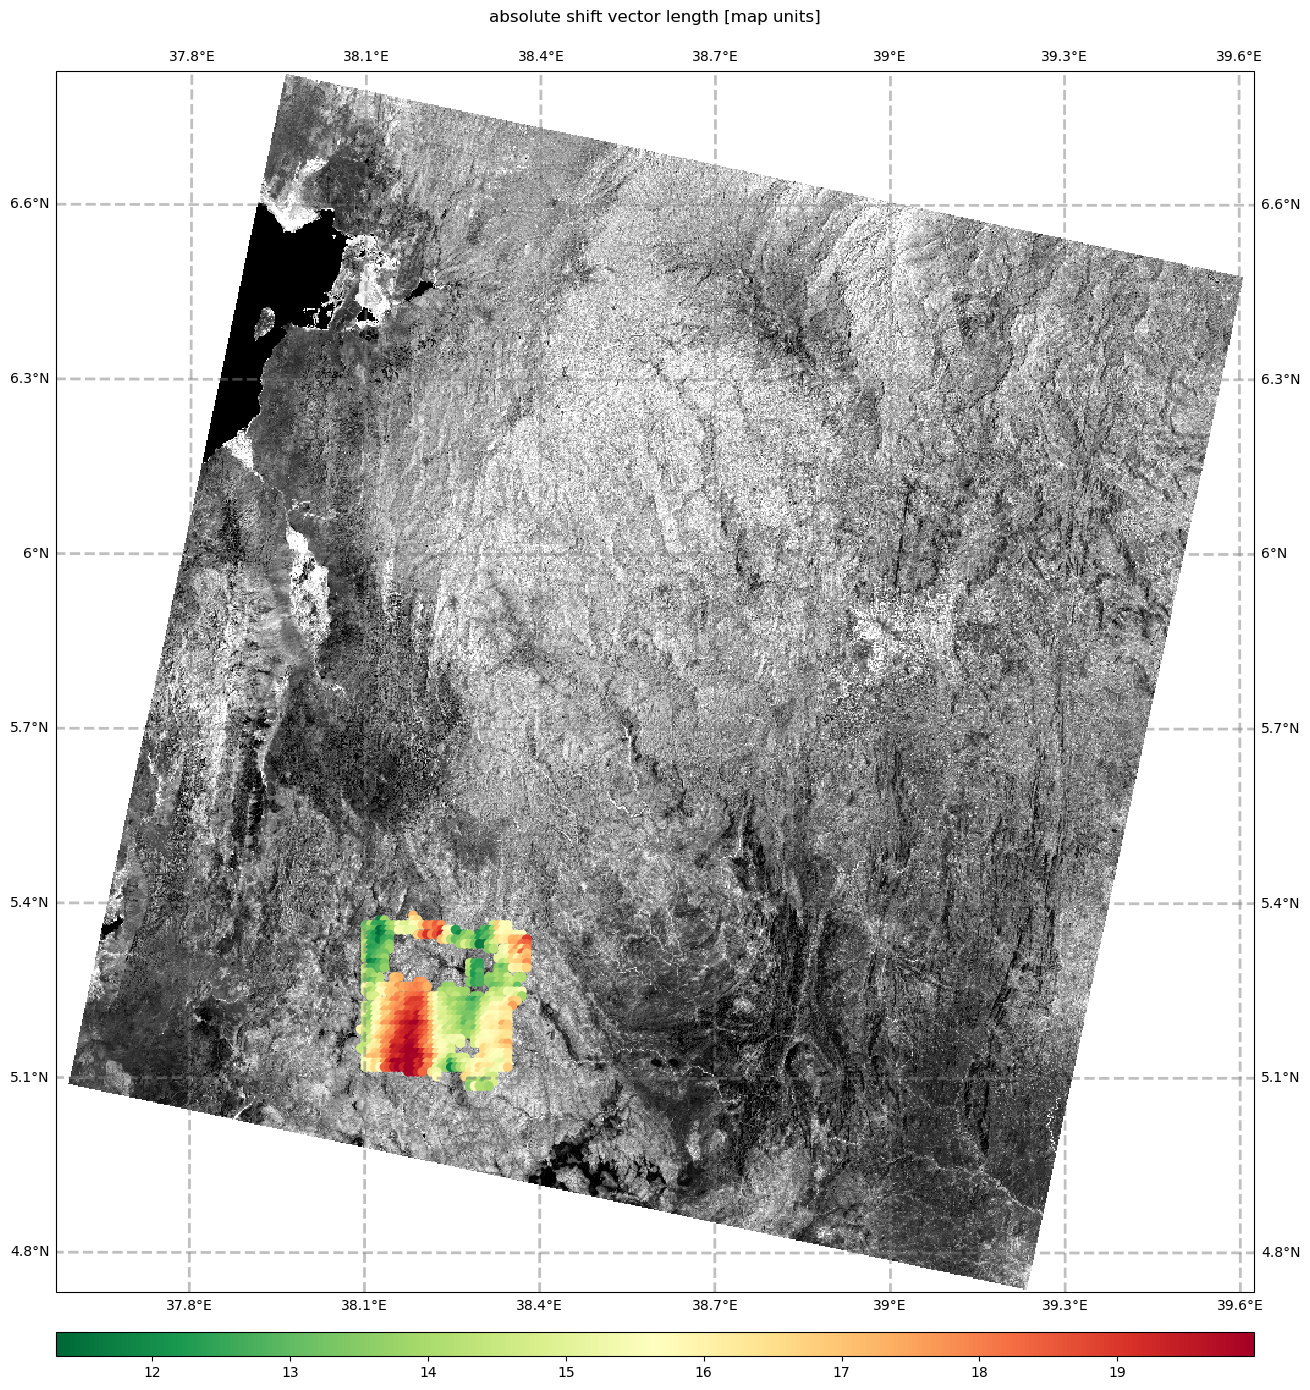

In [4]:
CRL_after_corr = COREG_LOCAL(str(im_reference), CRL.path_out, grid_res=30)

CRL_after_corr.COREG_obj.shift.band4match = 0
CRL_after_corr.view_CoRegPoints(figsize=(15,15),backgroundIm='ref')

## 2. Radiometric correction ##

**2.1. Import required libraries and define paths** 

In [5]:
import rasterio
import numpy as np
import os

# Path to the geometrically corrected image (AROSICS output)
input_image = output_dir / "Prisma_L2D_STD_20230125__shifted_to__Landsat_reference_B5.bsq"

# Output directory
output_dir = output_dir
print('Done!')

Done!


**2.2. Convert .bsq to .GEotiff format** 

In [6]:
with rasterio.open(input_image) as src:
    data = src.read()          
    meta = src.meta.copy()     

print(f"Original number of bands: {data.shape[0]}")
print(f"Original driver: {meta['driver']}")


# Update metadata to write a GeoTIFF
meta.update({
    "driver": "GTiff"})

Original number of bands: 230
Original driver: ENVI


**2.3. Define bands to remove** 

In [7]:
bands_to_remove = [
    1, 44, 59, 60, 61, 62, 78, 79, 80, 81, 98, 99, 100, 101, 102, 103, 104, 105, 
    106, 107, 108, 109, 110, 111, 142, 143, 144, 145, 146, 147, 148, 149, 150, 
    151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 
    166, 167, 210, 211, 212, 213, 214, 215]

# Convert band numbers to 0-based indexing (Python standard)
bands_to_remove = [b - 1 for b in bands_to_remove]
print('Done!')

Done!


**2.4. Remove bands** 

In [8]:
# Select bands to keep
bands_to_keep = [i for i in range(data.shape[0]) if i not in bands_to_remove]

# Filter bands
filtered_data = data[bands_to_keep, :, :]

print(f"Number of bands after removal: {filtered_data.shape[0]}")

# Replace zero values with NaN (invalid or no-data pixels)
filtered_data = np.where(filtered_data == 0, np.nan, filtered_data)

# Update metadata for output image
meta.update({
    "count": filtered_data.shape[0],
    "dtype": "float32"})

Number of bands after removal: 175


**2.5. Save the corrected image** 

In [9]:
# Output file path
output_path = os.path.join(
    output_dir,
    "Prisma_L2D_STD_20230125_corrected.tif")

# Write the filtered raster to disk
with rasterio.open(output_path, "w", **meta) as dst:
    dst.write(filtered_data.astype("float32"))

print('Output saved')

Output saved
